In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ax.api.client import Client
from ax.api.configs import RangeParameterConfig
from ax.generation_strategy.generation_strategy import GenerationStrategy
from ax.generation_strategy.generation_node import GenerationNode
from ax.generation_strategy.model_spec import GeneratorSpec
from ax.modelbridge.registry import Generators
from ax.utils.stats.model_fit_stats import MSE
from botorch.models import SingleTaskGP
from ax.models.torch.botorch_modular.surrogate import SurrogateSpec, ModelConfig
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
import plotly.express as px

from gpytorch.kernels import MaternKernel
from ax.models.torch.botorch_modular.kernels import DefaultRBFKernel, ScaleMaternKernel
from gpytorch.kernels.linear_kernel import LinearKernel
from gpytorch.kernels.rbf_kernel import RBFKernel

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Test/Train Split

This section of code obtains a test/train split that does not suffer from test/train leakage by spatial proximity.

In [2]:
GrdSrch_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-A1_PGCI-GrdSrch-[27]-P3O1/raw-data_2023-03-10_PtA1-PGCI-GrdSrch-[27]-P3O1_Stykke-4.csv")
RndSrch_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-A2_PGCI-RndSrch-[27]-P3O1/raw-data_2023-03-10_PtA2-PGCI-RndSrch-[27]-P3O1_Stykke-4.csv")
GrdSrch_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)
RndSrch_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)
BOpt_8SP_3It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-B5_PGCI-BOpt-[8,3,3,3,3,3,3,1]-P3O1/raw-data_2023-03-20_PtB5-PGCI-BOpt-[8,3,3,3,3,3,3,1]-P3O1-Stykke-4.csv")
BOpt_8SP_3It_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)

In [3]:
df = pd.concat(objs=[GrdSrch_df,RndSrch_df,BOpt_8SP_3It_df])
df.drop(columns=["mould_position","G_stoichiometry","CA_stoichiometry","IA_stoichiometry","StartPolymerMass_g","EndPolymerMass_pct"],inplace=True)
df['DeltaPolymerMass_pct']=df['DeltaPolymerMass_pct']*-1
df

,s1,s2,b1,DeltaPolymerMass_pct
0,0.8000,1.0000,0.8000,13.360997
1,1.0000,0.4000,0.6000,12.188133
2,0.4000,0.6000,0.8000,14.405027
3,0.8000,0.8000,1.0000,10.823033
4,0.4000,0.8000,0.6000,14.041169
...,...,...,...,...
24,0.4413,0.9805,0.5755,11.473868
25,0.4925,0.8819,0.5811,12.517877
26,0.3829,0.6579,0.7756,16.666833
27,0.3349,0.6460,0.7712,17.279822


In [4]:
def PredictorsToCaStoichs(s1,b1):
    return (0.5+(2.0-0.5)*s1)*b1

def PredictorsToIaStoichs(s2,b1):
    return (1.0+(2.0-1.0)*s2)*(1-b1)

In [5]:
CaStoichs = []
for s1,b1 in zip(df["s1"],df["b1"]):
    CaStoichs.append(PredictorsToCaStoichs(s1,b1))
IaStoichs = []
for s2,b1 in zip(df["s2"],df["b1"]):
    IaStoichs.append(PredictorsToIaStoichs(s2,b1))
CaStoichs = np.array(CaStoichs)
IaStoichs = np.array(IaStoichs)

In [6]:
df = df.drop(columns=["s1","s2","b1"])
df["n_ci"] = CaStoichs
df["n_it"] = IaStoichs
df

,DeltaPolymerMass_pct,n_ci,n_it
0,13.360997,1.360000,0.400000
1,12.188133,1.200000,0.560000
2,14.405027,0.880000,0.320000
3,10.823033,1.700000,0.000000
4,14.041169,0.660000,0.720000
...,...,...,...
24,11.473868,0.668702,0.840722
25,12.517877,0.719838,0.788328
26,16.666833,0.833266,0.372033
27,17.279822,0.773012,0.376605


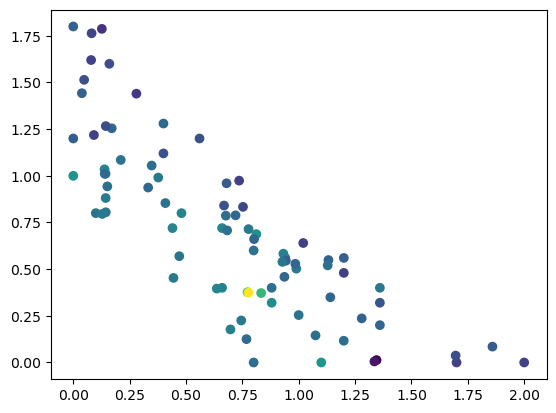

In [7]:
# Plotting the Data
plt.scatter(df["n_ci"],df["n_it"],c=df["DeltaPolymerMass_pct"])

In [8]:
X = df[["n_ci","n_it"]].to_numpy()
y = df["DeltaPolymerMass_pct"].to_numpy()

In [9]:
# def distance(p1, p2):
#     return math.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)

# def minDistance(points):
#     n = len(points)
    
#     minDist = float('inf')  

#     # Brute force to check all pairs
#     for i in range(n):
#         for j in range(i + 1, n):
#             dist = distance(points[i], points[j])
#             if dist < minDist:
#                 minDist = dist
    
#     # Return the smallest distance
#     return minDist

In [10]:
# Train/Test Split
# Making Sure the Split doesn't allow test/train bleed spatially.
# r1 = 0
# r2 = 10000
# SeedRange = list(range(r1,r2))
# ConsideredSeeds = []

# for Seed in SeedRange:
#     X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,random_state=Seed)
#     ClosestSamples = []
#     for x_test in X_test:
#         SampleClosenesses = []
#         test_n_ci = x_test[0]
#         test_n_it = x_test[1]
#         for x_train in X_train:
#             train_n_ci = x_train[0]
#             train_n_it = x_train[1]
#             Distance = minDistance([[test_n_ci,test_n_it],[train_n_ci,train_n_it]])
#             SampleClosenesses.append(Distance)
#         ClosestSample = np.min(np.array(SampleClosenesses))
#         ClosestSamples.append(ClosestSample)
#     if np.min(ClosestSamples) > 0.02 and np.average(ClosestSamples) > 0.1:
#         ConsideredSeeds.append(Seed)

# print(len(ConsideredSeeds))

In [11]:
# Finding a seed which is most suitable given the constraints:
# 1) test points should not overlap with train.
# 2) train points should be fairly representatively spread over the parameter space.
# 3) there should be at least one test point that is high delta m!

# for count,seed in enumerate(ConsideredSeeds):
#     X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,random_state=seed)
#     if count == 25:
#         print(seed)
    # plt.scatter(X_train.T[0],X_train.T[1],c=y_train)
    # plt.scatter(X_test.T[0],X_test.T[1],c="red",s=1)
    # plt.text(x=0.00,y=0.00,s=f"{count}")
    # plt.show()
    # if count == 100:
    #     break

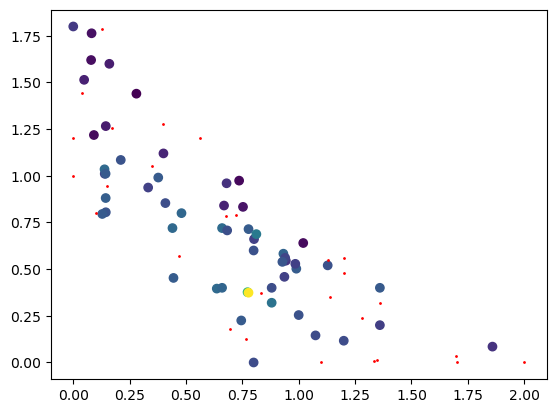

In [12]:
# Displaying the finally selected seed.
# 3863 is pretty good, fulfills all criteria well.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,random_state=3863)
plt.scatter(X_train.T[0],X_train.T[1],c=y_train)
plt.scatter(X_test.T[0],X_test.T[1],c="red",s=1)

In [13]:
# Finding the ultimate bounds of the stochiometric space.
# PredictorsToCaStoichs(0,0) # 0.0
# PredictorsToCaStoichs(0,1) # 0.5
# PredictorsToCaStoichs(1,0) # 0.0
# PredictorsToCaStoichs(1,1) # 2.0
# So for n_ci the bounds are between 0 and 2.

# PredictorsToIaStoichs(0,0) # 1.0
# PredictorsToIaStoichs(0,1) # 0.0
# PredictorsToIaStoichs(1,0) # 2.0
# PredictorsToIaStoichs(1,1) # 0.0
# So for n_it the bounds are between 0 and 2.

# Training

This section of code considers the training of a model based on the train data.

In [14]:
client = Client()

parameters = [
    RangeParameterConfig(
        name="n_ci", parameter_type="float", bounds=(0, 2)
    ),
    RangeParameterConfig(
        name="n_it", parameter_type="float", bounds=(0, 2)
    ),
]

client.configure_experiment(parameters=parameters)

In [15]:
def construct_generation_strategy(
    generator_spec: GeneratorSpec, node_name: str,
) -> GenerationStrategy:
    """Constructs a Center + Sobol + Modular BoTorch `GenerationStrategy`
    using the provided `generator_spec` for the Modular BoTorch node.
    """
    botorch_node = GenerationNode(
        node_name=node_name,
        model_specs=[generator_spec],
    )
    return GenerationStrategy(
        name=f"{node_name}",
        nodes=[botorch_node]
    )

construct_generation_strategy(
    generator_spec=GeneratorSpec(model_enum=Generators.BOTORCH_MODULAR),
    node_name="Modular BoTorch",
)

GenerationStrategy(name='Modular BoTorch', nodes=[GenerationNode(node_name='Modular BoTorch', model_specs=[GeneratorSpec(model_enum=BoTorch, model_key_override=None)], transition_criteria=[])])

In [16]:
surrogate_spec = SurrogateSpec(
    model_configs=[
        ModelConfig(
            botorch_model_class=SingleTaskGP,

            covar_module_class=MaternKernel,
            covar_module_options={"nu": 2.5},

            # covar_module_class=MaternKernel,
            # covar_module_options={"nu": 1.5},

            # covar_module_class=MaternKernel,
            # covar_module_options={"nu": 0.5},

            # covar_module_class=RBFKernel,
        ),
    ],
    eval_criterion=MSE,
    allow_batched_models=False,
)

In [17]:
generator_spec = GeneratorSpec(
    model_enum=Generators.BOTORCH_MODULAR,
    model_kwargs={
        "surrogate_spec": surrogate_spec,
        "botorch_acqf_class": qLogNoisyExpectedImprovement,
        "acquisition_options": {},
    },
    model_gen_kwargs = {
        "model_gen_options": {
            "optimizer_kwargs": {
                "num_restarts": 20,
                "sequential": False,
                "options": {
                    "batch_limit": 5,
                    "maxiter": 200,
                },
            },
        },
    }
)

In [18]:
generation_strategy = construct_generation_strategy(
    generator_spec=generator_spec,
    node_name="BoTorch w/ Model Selection",
)
client.set_generation_strategy(
    generation_strategy=generation_strategy,
)

In [19]:
metric_name = "t1"
objective = f"{metric_name}"

client.configure_optimization(objective=objective)

In [20]:
for array,target in zip(X_train,y_train):
    my_parameters = {"n_ci": array[0], "n_it": array[1]}
    trial_index = client.attach_trial(parameters=my_parameters)
    client.complete_trial(trial_index=trial_index,raw_data={"t1": target})

In [21]:
client.summarize()

,trial_index,arm_name,trial_status,t1,n_ci,n_it
0,0,0_0,COMPLETED,11.412587,0.048221,1.514236
1,1,1_0,COMPLETED,12.463182,0.332165,0.937180
2,2,2_0,COMPLETED,11.025825,0.752841,0.833635
3,3,3_0,COMPLETED,14.405027,0.880000,0.320000
4,4,4_0,COMPLETED,14.041169,0.660000,0.720000
5,5,5_0,COMPLETED,13.957990,0.440000,0.720000
6,6,6_0,COMPLETED,10.717052,1.020000,0.640000
7,7,7_0,COMPLETED,14.007758,0.636520,0.395759
8,8,8_0,COMPLETED,11.305263,0.160000,1.600000
9,9,9_0,COMPLETED,13.875438,0.480000,0.800000


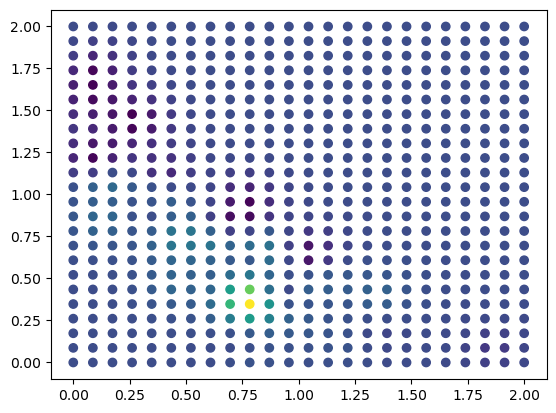

In [22]:
client.get_next_trials(max_trials=1)
client.predict([{"n_ci":0.1,"n_it":0.1}])[0]["t1"][0]

n = 25
iCoords_arr = np.linspace(0,2,n-1)
jCoords_arr = np.linspace(0,2,n-1)

ijCoords_lis = []
ijCoords_lis_nonDict = []
for i in iCoords_arr:
    for j in jCoords_arr:
        ijCoords_lis.append({"n_ci":i,"n_it":j})
        ijCoords_lis_nonDict.append([i,j])
y_pred = client.predict(ijCoords_lis)
y_pred_lis = []
for i in y_pred:
    y_pred_lis.append(i["t1"][0])

n_ci_bits = np.array(ijCoords_lis_nonDict).T[0]
n_it_bits = np.array(ijCoords_lis_nonDict).T[1]
plt.scatter(x=n_ci_bits,y=n_it_bits,c=y_pred_lis,cmap='viridis')

# Naive Validation

In [25]:
y_pred = []
for i,j in zip(X_test,y_test):
    y_pred.append(client.predict([{"n_ci":i[0],"n_it":i[1]}])[0]["t1"][0])
y_pred = np.array(y_pred)

rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"RMSE =\t{round(rmse,3)}")
print(f"MSE =\t{round(mse,3)}")

# nu =      2.5
# rmse =    1.444
# mse =     2.085

RMSE =	1.444
MSE =	2.085


Text(0, 0.5, 'Predictions, $y_{pred}$')

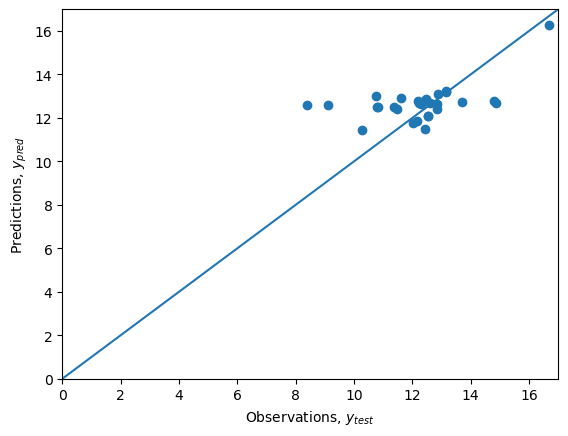

In [24]:
plt.scatter(y_test,y_pred)
plt.plot([0,17],[0,17])
plt.ylim(0,17)
plt.xlim(0,17)
plt.xlabel(r"Observations, $y_{test}$")
plt.ylabel(r"Predictions, $y_{pred}$")

Text(0, 0.5, 'Residuals, $y_{test}-y_{pred}$')

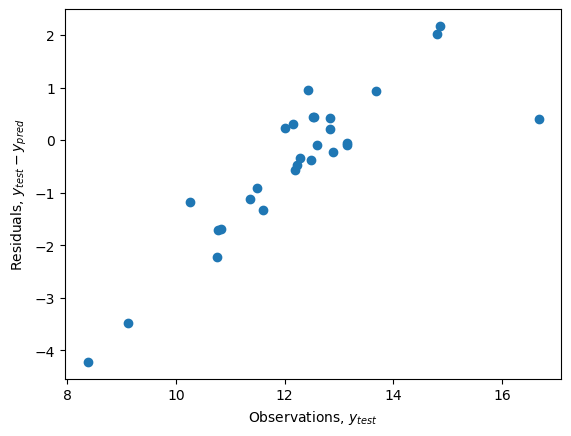

In [25]:
y_residuals = y_test-y_pred
plt.scatter(y_test,y_residuals)
# plt.plot([0,17],[0,17])
plt.xlabel(r"Observations, $y_{test}$")
plt.ylabel(r"Residuals, $y_{test}-y_{pred}$")

# Save Model

In [26]:
client.save_to_json_file('ModelGP_Matern25.json')